# CMS JetHT 2016 - Jet Analysis

## Overview
This notebook analyzes jet data from a CMS experiment conducted at the LHC in 2016, using a data set from the CERN Open Data Portal. Jets are the experimental signature of quark and gluon hadronization; when quarks and/or gluons are produced in a collision, they fragment into a spray of particles called jets. This analysis looks at the basic kinematic properties of those jets.

## Dataset
- **Source:** CERN Open Data Portal
- **Dataset:** /JetHT/Run2016G-UL2016_MiniAODv2_NanoAODv9-v1/NANOAOD
- **Events Analyzed:** 107,505
- **Format:** NanoAOD (read using uproot)

## Selection Cuts
- Jet $p_T$ > 30 GeV
- |Jet $\eta$| < 2.4

## Plots
1. **Jet $p_T$ distribution** - Steeply falling spectrum characteristics of QCD
2. **Jet $\eta$ distribution** - symmetric around 0, reflecting detectior geometry
3. **Jet $\phi$ distribution** - uniform, showing no detector bias
4. **Jet mass distribution** - reflects internal jet structure from hadronization
5. **Jet multiplicity** - average of 3.64 jets per event

In [50]:
import numpy as np
import matplotlib.pyplot as plt
import awkward as ak
from simulation import load_jet_data, filter_jets, get_jet_multiplicity

jets = load_jet_data('CD205112-3009-AB40-ACE1-9C3C31285B4A.root')
print(f"Loaded {len(jets)} events")

Loaded 107505 events


In [51]:
filtered_jets = filter_jets(jets)
total_jets = ak.sum(get_jet_multiplicity(filtered_jets))
print(f"Total jets after cuts: {total_jets}")
print(f"Average jets per event: {ak.mean(get_jet_multiplicity(filtered_jets)):.2f}")

Total jets after cuts: 391708
Average jets per event: 3.64


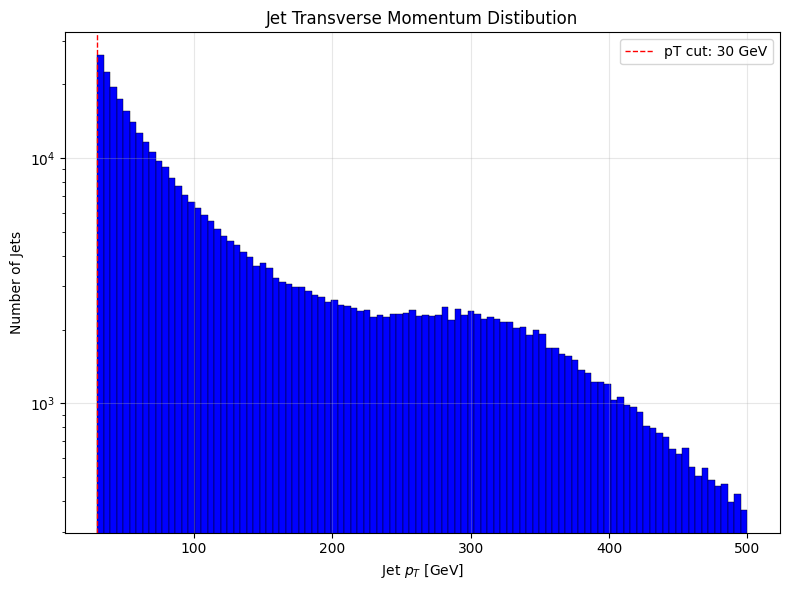

In [52]:
pt_values=ak.to_numpy(ak.flatten(filtered_jets['Jet_pt']))

plt.figure(figsize=(8,6))
plt.hist(pt_values, bins=100, range=(30,500), color='blue', edgecolor='k',linewidth=0.3)
plt.xlabel('Jet $p_T$ [GeV]')
plt.ylabel('Number of Jets')
plt.title('Jet Transverse Momentum Distibution')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.axvline(x=30, color='red', linestyle='--', linewidth=1, label='pT cut: 30 GeV')
plt.legend()
plt.tight_layout()
plt.savefig('jet_pt_distrribution.png', dpi=150)
plt.show()

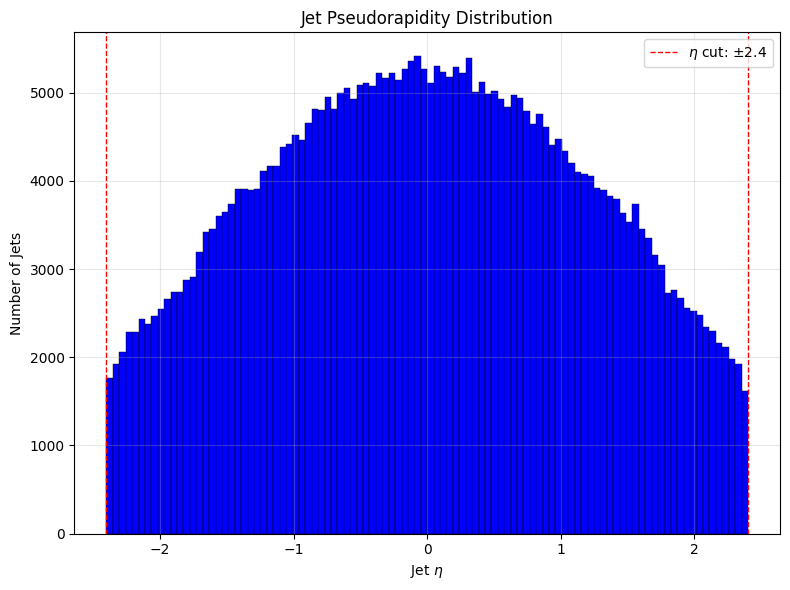

In [53]:
eta_values=ak.to_numpy(ak.flatten(filtered_jets['Jet_eta']))

plt.figure(figsize=(8,6))
plt.hist(eta_values,bins=100, range=(-2.4,2.4),color='blue', edgecolor='k',linewidth=0.3)
plt.xlabel(r'Jet $\eta$')
plt.ylabel('Number of Jets')
plt.grid(True,alpha=0.3)
plt.title('Jet Pseudorapidity Distribution')
plt.axvline(x=2.4, color='red', linestyle='--', linewidth=1, label=r'$\eta$ cut: ±2.4')
plt.axvline(x=-2.4, color='red', linestyle='--', linewidth=1)
plt.legend()
plt.tight_layout()
plt.savefig('jet_eta_distribution.png',dpi=150)
plt.show()

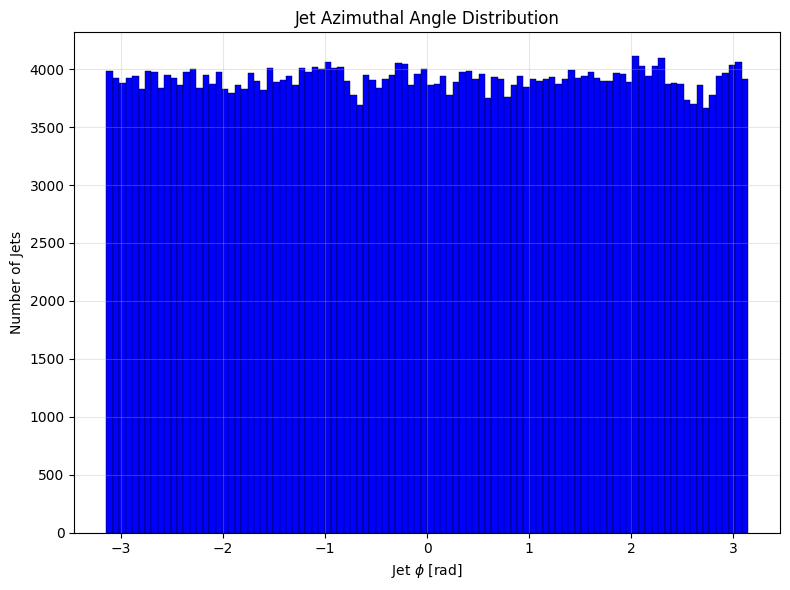

In [54]:
phi_values=ak.to_numpy(ak.flatten(filtered_jets['Jet_phi']))

plt.figure(figsize=(8,6))
plt.hist(phi_values,bins=100, range=(-np.pi,np.pi),color='blue', edgecolor='k',linewidth=0.3)
plt.xlabel(r'Jet $\phi$ [rad]')
plt.ylabel('Number of Jets')
plt.grid(True,alpha=0.3)
plt.title('Jet Azimuthal Angle Distribution')
plt.tight_layout()
plt.savefig('jet_phi_distribution.png',dpi=150)
plt.show()

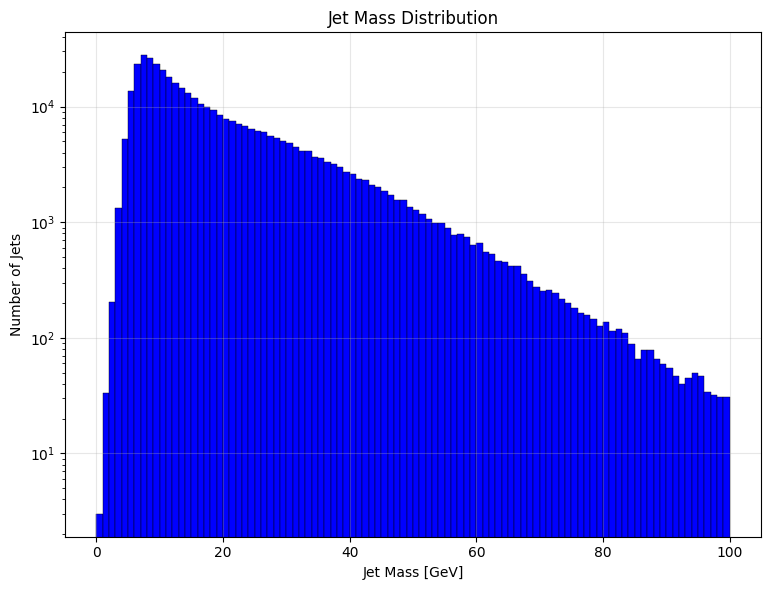

In [55]:
mass_values=ak.to_numpy(ak.flatten(filtered_jets['Jet_mass']))

plt.figure(figsize=(8,6))
plt.hist(mass_values,bins=100, range=(0,100),color='blue', edgecolor='k',linewidth=0.3)
plt.xlabel('Jet Mass [GeV]')
plt.ylabel('Number of Jets')
plt.grid(True,alpha=0.3)
plt.title('Jet Mass Distribution')
plt.tight_layout()
plt.yscale('log')
plt.savefig('jet_mass_distribution.png',dpi=150)
plt.show()

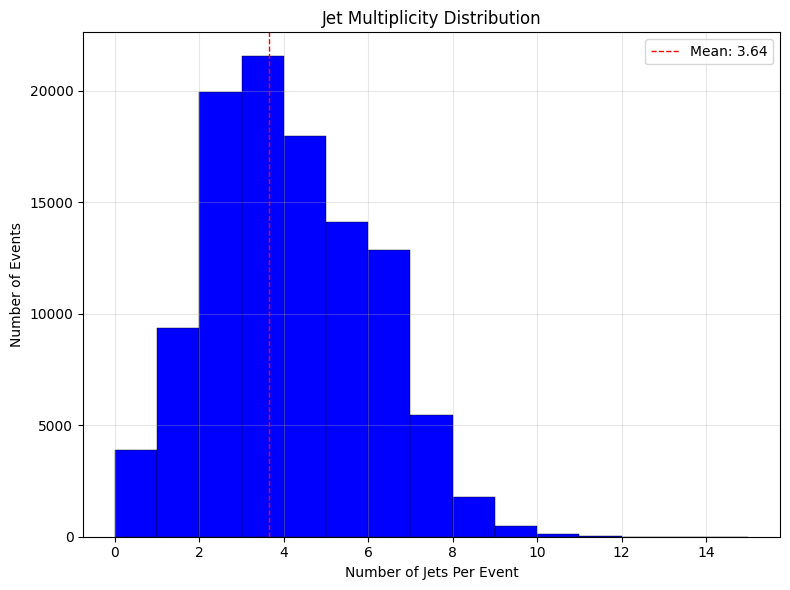

In [56]:
mult_values=ak.to_numpy(get_jet_multiplicity(filtered_jets))

plt.figure(figsize=(8,6))
plt.hist(mult_values,bins=15, range=(0,15),color='blue', edgecolor='k',linewidth=0.3)
plt.xlabel('Number of Jets Per Event')
plt.ylabel('Number of Events')
plt.grid(True,alpha=0.3)
plt.title('Jet Multiplicity Distribution')
plt.axvline(x=ak.mean(get_jet_multiplicity(filtered_jets)), color='red', linestyle='--', linewidth=1, label=f'Mean: {float(ak.mean(get_jet_multiplicity(filtered_jets))):.2f}')
plt.legend()
plt.tight_layout()
plt.savefig('jet_mult_distribution.png',dpi=150)
plt.show()
